<div align="center">

# <span style="color: #3498db;">CA3 - ML</span>

**<span style="color:rgb(213, 213, 213);">Mohammad Hossein Mazaheri</span> - <span style="color:rgb(152, 152, 186);">810102585</span>**

</div>

# Summary

## Introduction
- [Introduction](#Introduction)  
  Overview and purpose of the analysis.


## First: Data Exploration

### 1. Setup
- [Import Necessary Libraries](#Import-libraries)
- [Load File](#Load-File)

#### 2. Data Analyse
- [Heatmap of Correlation Analysis](#Correlation-Heatmap)
- [Histograms of Numerical Features](#Histograms-of-Numerical-Features)
- [Grade Distribution](#Grade-Distribution)
- [Show categorical feature](#Show-categorical-feature)
- [Summary Statistics](#Numerical-Features)


## Second: Feature Engineering and Data Preprocessing
- [Data Cleaning](#data-cleaning)
- [Remove not usable Data](#remove-not-usable-data)
- [Encoding Dataset](#encoding-dataset)
- [Classification labels](#classification-labels)

## Third: Model Development and Evaluation
- [Train Test Split](#train-test-split)
- [Normalization/Standardization](#normalizationstandardization)
- [Sklearn Models](#sklearn-models)
- [Check and test our model and accuracy](#check-and-test-our-model-and-accuracy)
- [Decision Tree from Scratch](#decision-tree-from-scratch)

In [ ]:
"-------------------------------------------------------------- Introduction -----------------------------------------------------------------------"

## Introduction

This project explores machine learning techniques to predict students' final grades in an Artificial Intelligence course, based on demographic, social, and academic attributes. The dataset consists of various student-related factors, such as age, gender, study time, parental education, university choice, extracurricular activities, and more. The goal is to analyze how these variables contribute to academic performance and build predictive models for classification.

In [ ]:
"------------------------------------------------------------ Data Exploration ---------------------------------------------------------------------"

## Import libraries

- Purpose: Import essential libraries and tools.

- Functions:

- Data manipulation: pandas, numpy

- Visualization: matplotlib, seaborn

- Preprocessing: StandardScaler, MinMaxScaler, RobustScaler

- Machine learning models: GaussianNB, DecisionTreeClassifier, RandomForestClassifier, XGBClassifier

- Model evaluation: classification_report, accuracy_score

In [421]:
"import Necessary Libraries"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score


## Load File
- Loads the dataset from the CSV file named *Grades.csv* into a DataFrame df.

In [ ]:
file_path = "data/Grades.csv"
df = pd.read_csv(file_path)

## Correlation Heatmap
- Computes a correlation matrix to see how strongly features are related to each other.

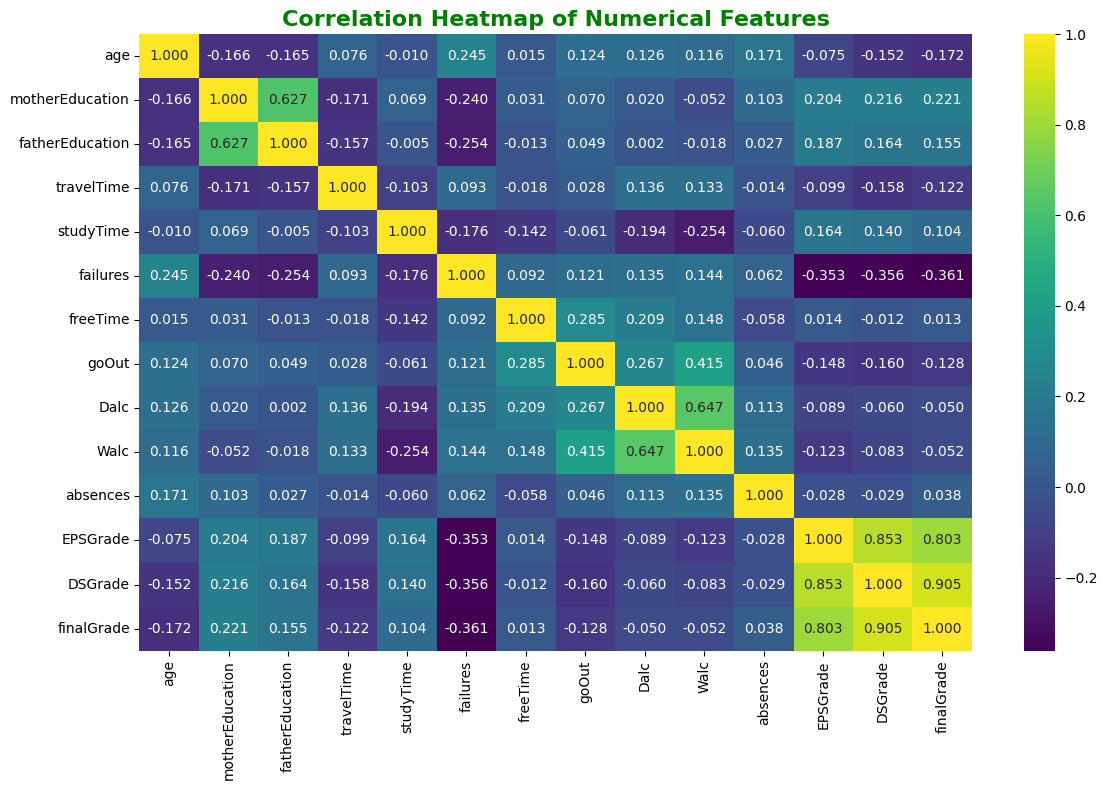

In [423]:
numerical_features = df.select_dtypes(include=['int64']).columns
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".3f")
plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold', color='green')
plt.tight_layout()
plt.show()


## Histograms of Numerical Features
- Plots histograms of numerical features to understand their distributions.

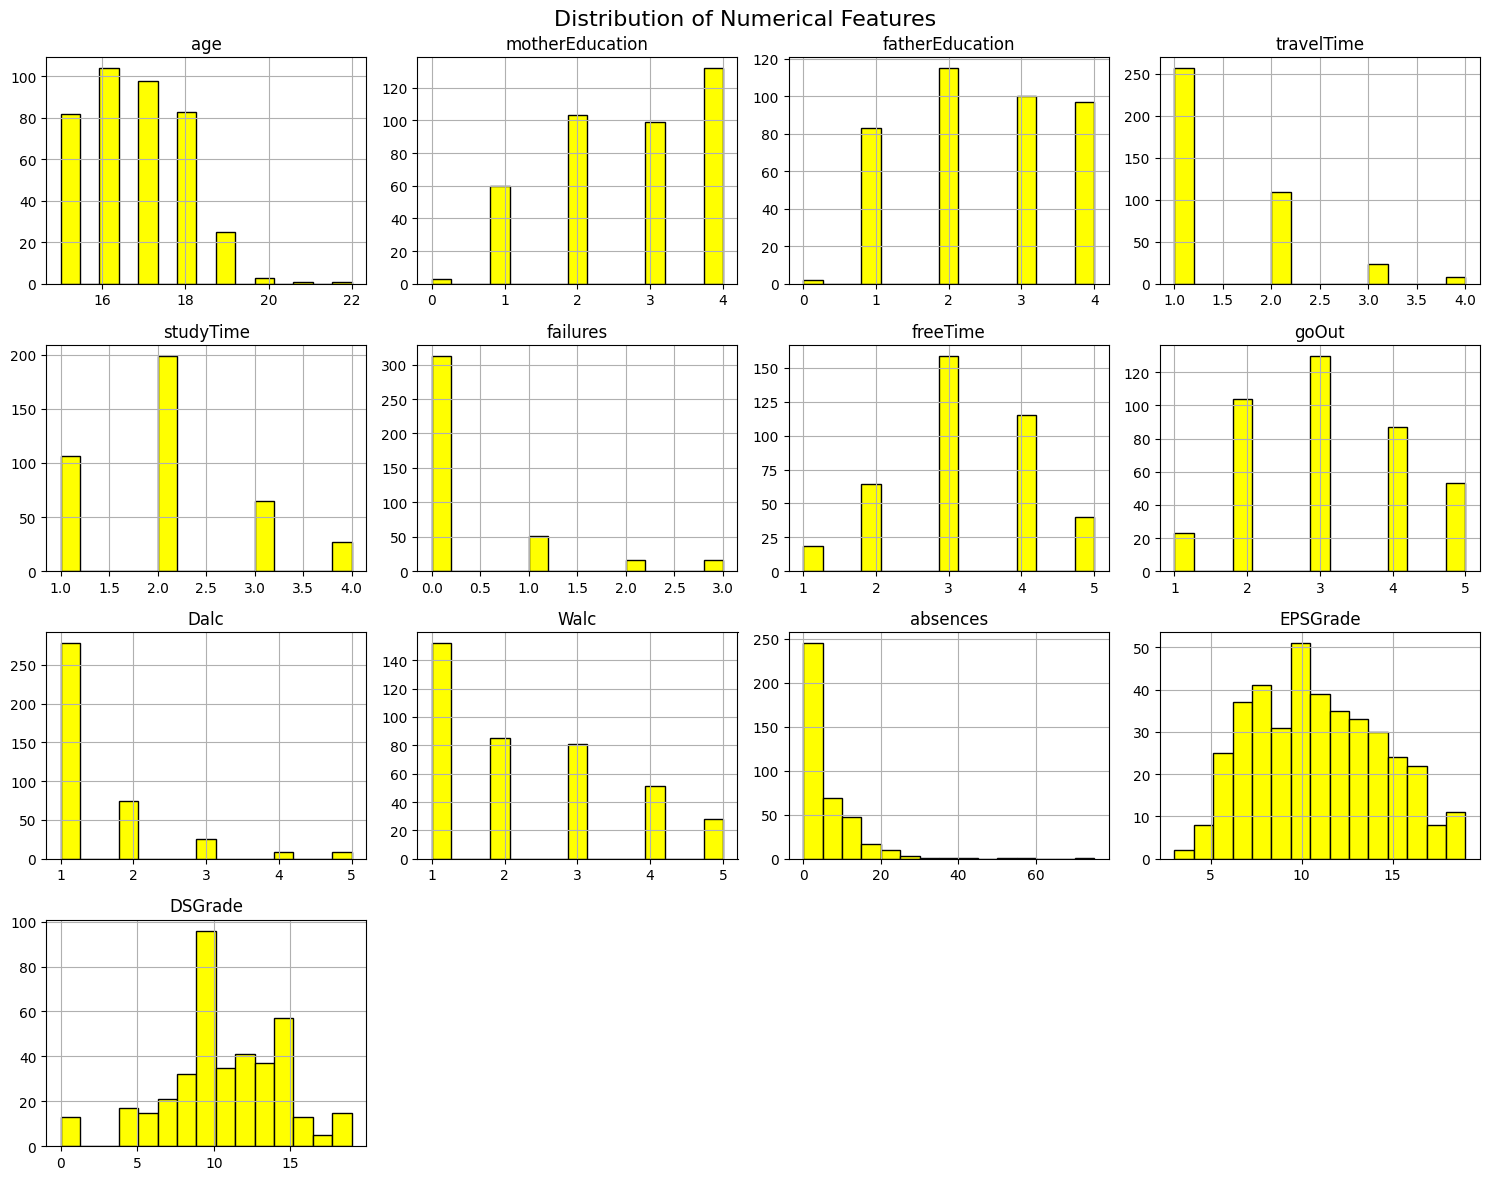

In [424]:
num_features = df[numerical_features].drop(columns=['finalGrade'])

num_features.hist(figsize=(15, 12), bins=15, color='yellow', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


## Grade Distribution

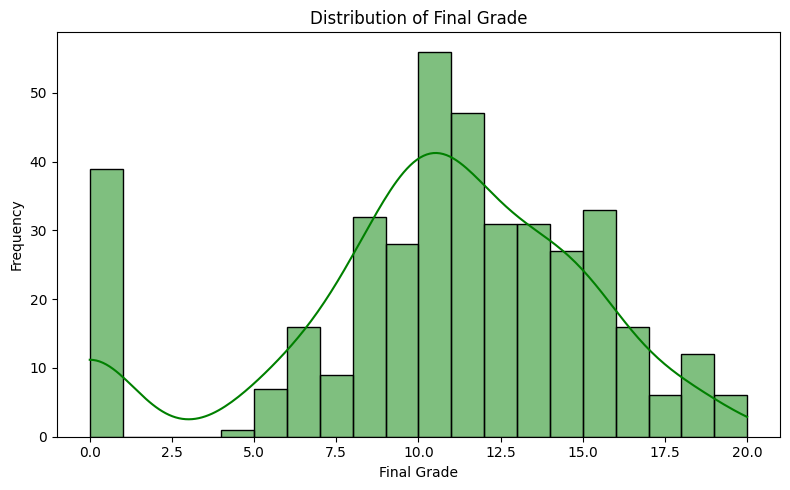

In [425]:
plt.figure(figsize=(8, 5))
sns.histplot(df['finalGrade'], kde=True, bins=20, color='green')
plt.title("Distribution of Final Grade")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Show categorical feature
- Visualize the distribution of categorical features in the dataset.

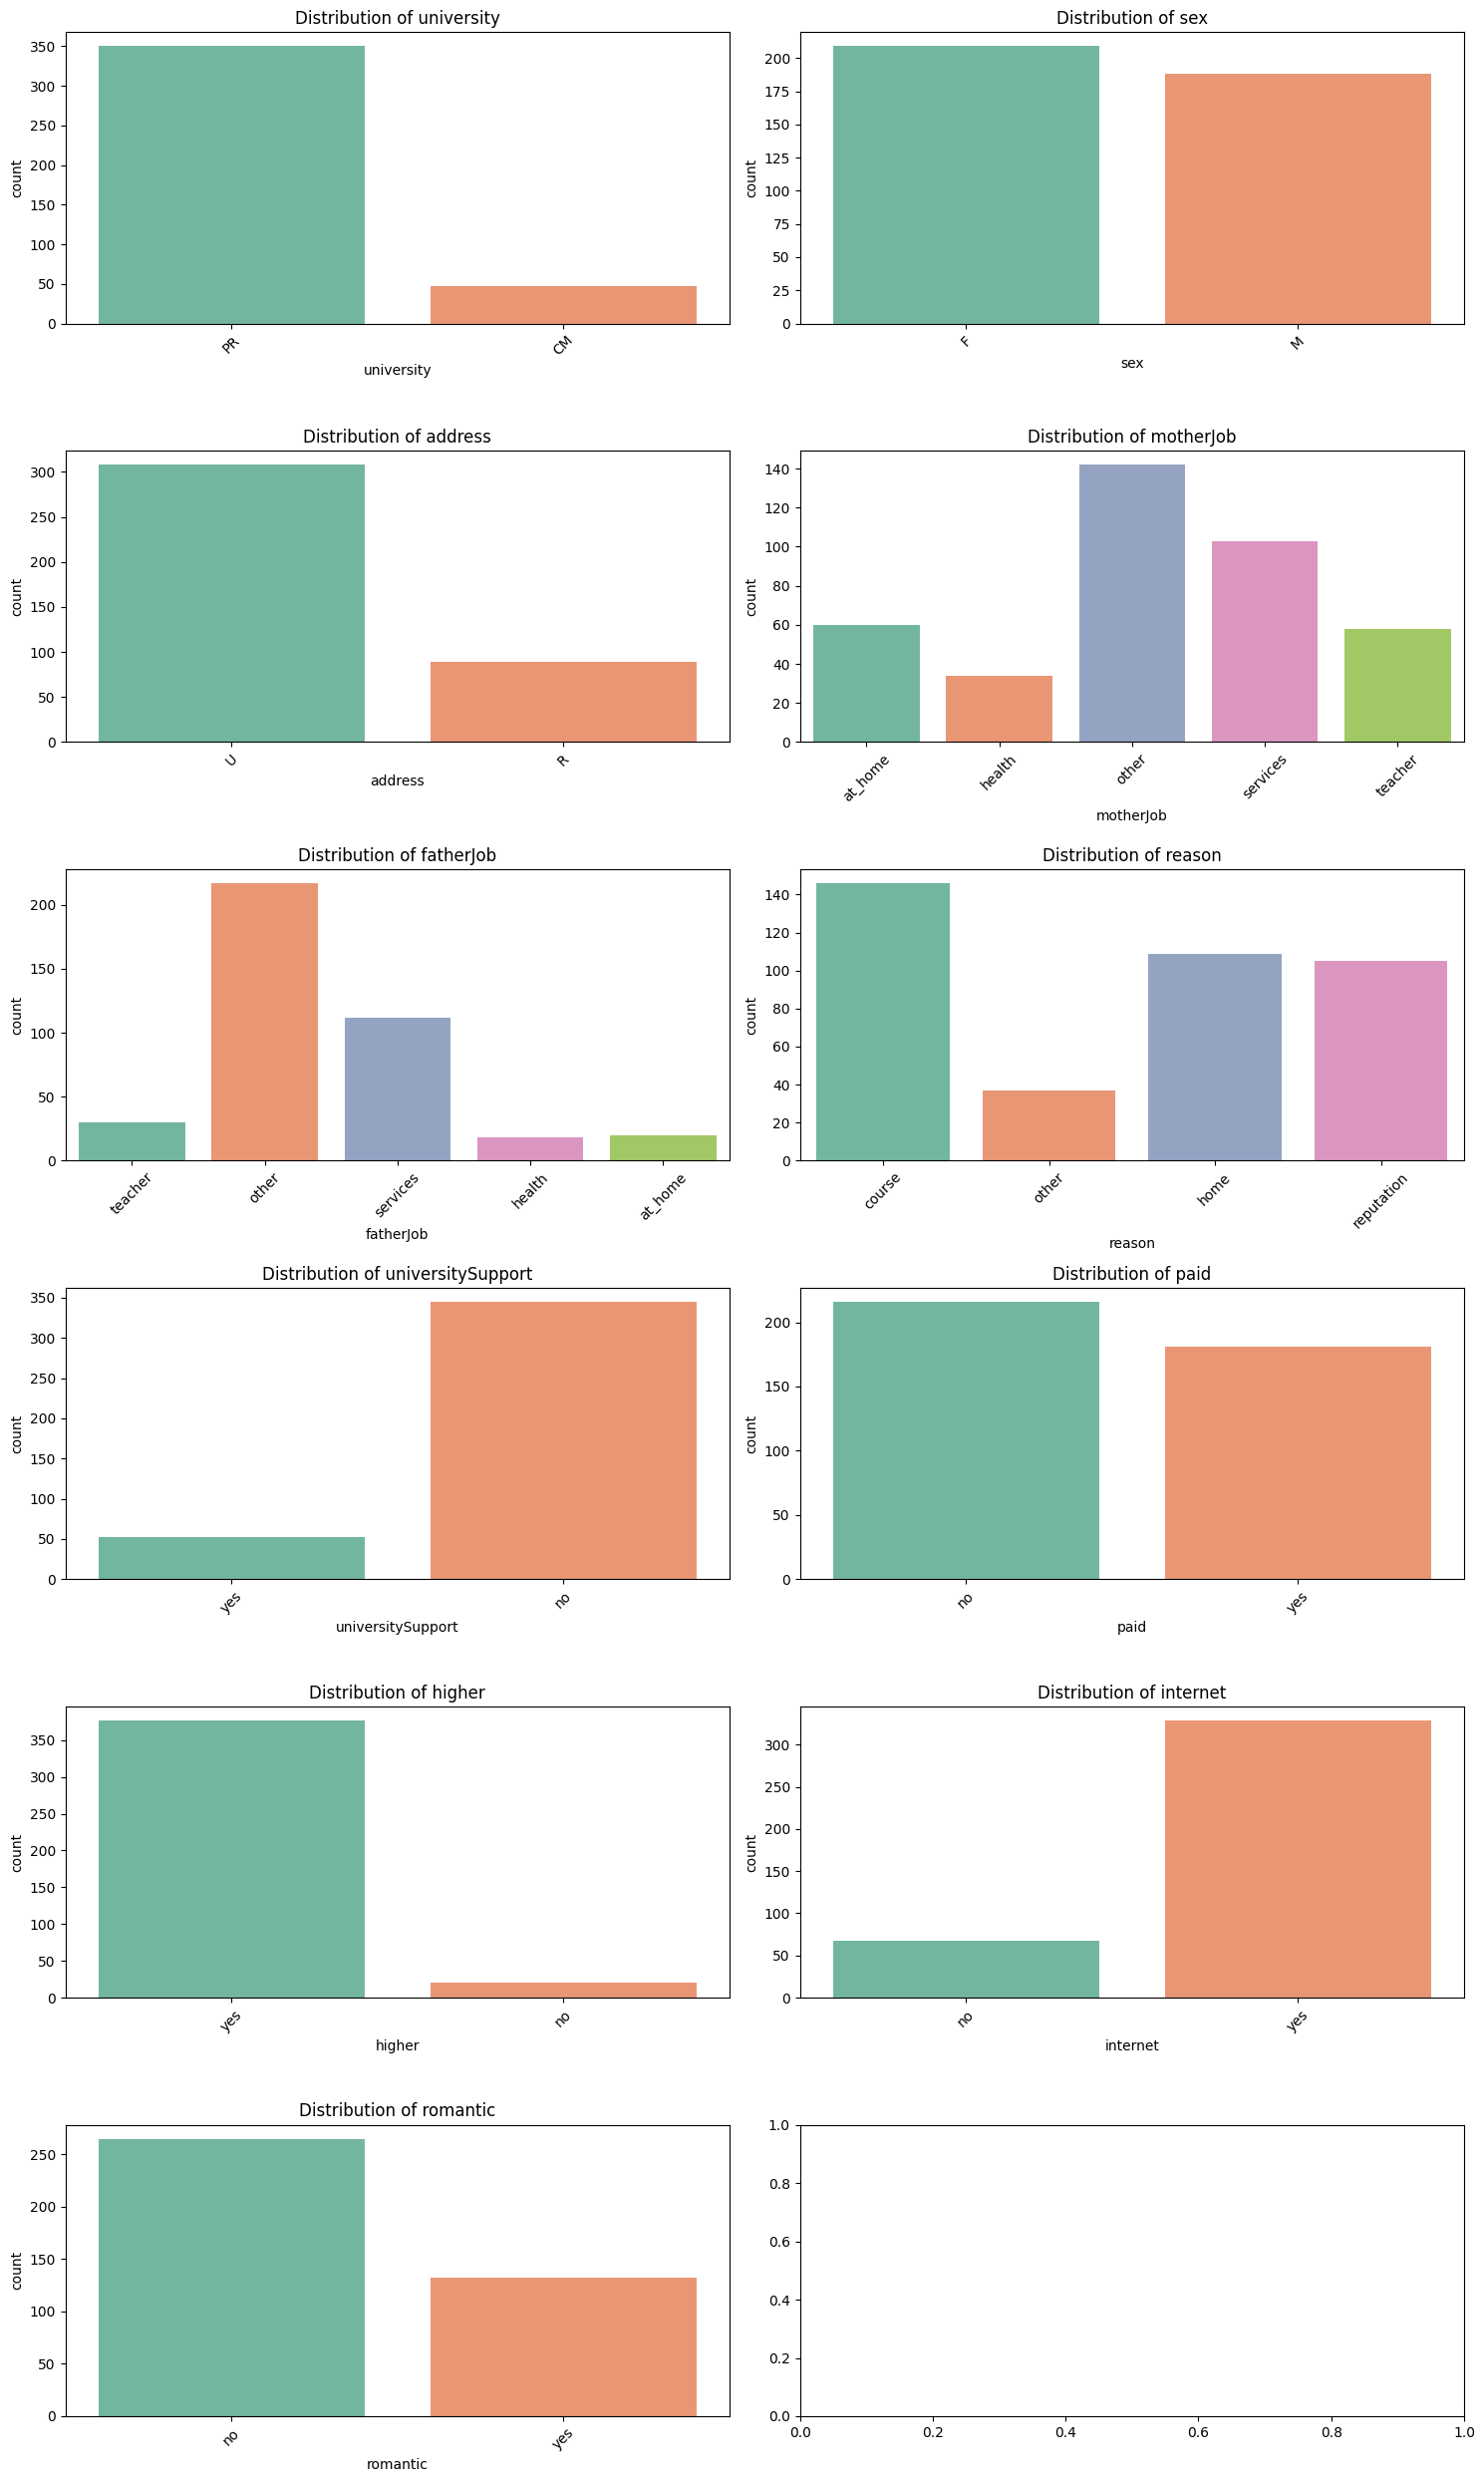

In [426]:
# Selecting categorical columns
categorical_features = df.select_dtypes(include=['object']).columns

# Plotting count plots for each categorical feature
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 📊 Summary of Exploratory Data Analysis

---

### Numerical Features

+ **Age** : Most students are between **15–19 years old**, with a peak at age 16.
- **Study Time** : Concentrated in the lower range, with most studying **less than 5 hours/week**.
+ **Failures** : Majority of students have **no previous academic failures**.
- **Absences** : Skewed right — most students have **low to moderate absences**, a few with high outliers.
+ **EPSGrade & DSGrade** : Scores are **generally well-distributed**; students tend to **perform better in DS**.
- **Final Grade** : Shows a **normal distribution** with peaks around 10.

---

### Correlation Analysis

- `finalGrade` is:
  - **Positively correlated** with `DSGrade` and `EPSGrade` → performance in related subjects is predictive.
  - **Negatively correlated** with `failures` and `absences` → academic success drops with more failures/absences.

---

### Categorical Features

- **University**: Majority from **PR (Princeton)**.
- **Sex**: Slightly more **female students**.
- **Address**: Most students are from **urban areas**.
- **Parental Education**: Varies widely, but **drops off at higher education levels**.
- **Parental Jobs**: Mostly classified as **"other"** or **"at_home"**.
- **University Support / Paid Classes**: Majority **do not receive extra support or tutoring**.
- **Internet / Romantic**: Most have **internet access**; fewer report romantic relationships.
- **Lifestyle (freeTime, goOut, Dalc, Walc)**: Generally **low to moderate activity and alcohol use**.

---

### ✅ Key Insights

- Focus on high-impact variables: **grades in other subjects, attendance, and failure history**.
- Prepare for feature engineering: **Binning `finalGrade` into categories**, encoding categorical variables.
- Normalize or transform skewed features for better model performance.

In [ ]:
"----------------------------------------------------- Feature Engineering and Data Preprocessing --------------------------------------------------"

## Data Cleaning:
---

### Missing Data
- No missing values were found in the dataset.
- If any appear:
  - **Numerical columns** should be filled with the **mean or median**.
  - **Categorical columns** should be filled with the **most frequent value (mode)**.

### Ambiguous or Out-of-Range Data
- **Age** values were checked for validity (should be between 15 and 22).
- **Categorical columns** were reviewed to ensure only valid entries exist (e.g., no typos or unknown categories).

In [427]:
missing_counts = df.isnull().sum()
missing_counts

university           0
sex                  0
age                  0
address              0
motherEducation      0
fatherEducation      0
motherJob            0
fatherJob            0
reason               0
travelTime           0
studyTime            0
failures             0
universitySupport    0
paid                 0
higher               0
internet             0
romantic             0
freeTime             0
goOut                0
Dalc                 0
Walc                 0
absences             0
EPSGrade             0
DSGrade              0
finalGrade           0
dtype: int64

## Remove not usable Data
- we remove three feature `fatherJob`, `motherJob`, and `reason` because has no direct or indirect effect on final grade (maybe influence less).

In [428]:
df = df.drop('fatherJob', axis='columns')
df = df.drop('motherJob', axis='columns')
df = df.drop('reason', axis='columns')

## Encoding Dataset
- Converts binary categorical features into numerical format, replacing "yes" with 1 and "no" with 0. Used for features like internet, higher, romantic, etc.
+ Encodes university names:

> - "PR" (Princeton University) → 1
> - "CM" (Carnegie Mellon University) → 0

- Encodes student residence types:

> - "U" (Urban) → 1
> - "R" (Rural) → 0

- Encodes gender:

> - "M" (Male) → 1
> - "F" (Female) → 0

In [429]:
df = df.replace({'yes': 1, 'no': 0})
df['university'] = df['university'].replace({'PR' : 1, 'CM' : 0}).astype('int64')
df['address'] = df['address'].replace({'U' : 1, 'R' : 0}).astype('int64')
df['sex'] = df['sex'].replace({'M' : 1, 'F' : 0}).astype('int64')

C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_21216\3019000006.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0})
C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_21216\3019000006.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['university'] = df['university'].replace({'PR' : 1, 'CM' : 0}).astype('int64')
C:\Users\HMazaheri\AppData\Local\Temp\ipykernel_21216\3019000006.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retai

## Classification labels
where grades are categorized into four distinct groups:

- Group A (Excellent): Scores above 17

- Group B (Good): Scores between 14 and 17

- Group C (Average): Scores between 10 and 14

- Group D (Failing): Scores below 10

In [430]:
def grade_to_category(grade):
    if grade >= 17:
        return 0
    elif grade >= 14:
        return 1
    elif grade >= 10:
        return 2
    else:
        return 3


df['finalGrade'] = df['finalGrade'].apply(grade_to_category)

In [ ]:
"------------------------------------------------------ Model Development and Evaluation -----------------------------------------------------------"

## Train Test Split

In [431]:
X = df.drop('finalGrade', axis=1)
y = df['finalGrade']

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: split temp into 80% test, 20% held-out
X_test, X_heldout, y_test, y_heldout = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp)

## Normalization/Standardization

In [432]:
def scale_features(df, scaler_type='standard', numerical_cols=None, exclude_cols=None):

    scaler_options = {
        'standard': StandardScaler,
        'minmax': MinMaxScaler,
        'robust': RobustScaler
    }
    
    if scaler_type not in scaler_options:
        raise ValueError(f"Invalid scaler type.")
    
    df_scaled = df.copy()
    
    if numerical_cols is None:
        numerical_cols = df.select_dtypes(include=['int64']).columns.tolist()
    
    if exclude_cols:
        numerical_cols = [col for col in numerical_cols if col not in exclude_cols]
    
    scaler = scaler_options[scaler_type]()
    df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    return df_scaled, scaler

In [433]:
X_train, scaler = scale_features(X_train)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_heldout = pd.DataFrame(scaler.transform(X_heldout), columns=X_heldout.columns, index=X_heldout.index)

## Sklearn Models

In [434]:
# 1. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

In [435]:
# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

In [436]:
# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [437]:
# 4. XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

c:\Users\HMazaheri\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:48:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Check and test our model and accuracy

In [438]:
# Evaluation helper
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Evaluate all models
evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("Decision Tree", y_test, dt_preds)
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


=== Naive Bayes ===
Accuracy: 0.6617647058823529
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.75      0.46         4
           1       0.41      0.54      0.47        13
           2       0.83      0.54      0.65        28
           3       0.83      0.87      0.85        23

    accuracy                           0.66        68
   macro avg       0.60      0.67      0.61        68
weighted avg       0.72      0.66      0.67        68


=== Decision Tree ===
Accuracy: 0.8676470588235294
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.77      0.87        13
           2       0.81      0.89      0.85        28
           3       0.87      0.87      0.87        23

    accuracy                           0.87        68
   macro avg       0.92      0.88      0.90        68
weighted avg       0.88      0.87  

In [439]:
final_model = rf_model  # or whichever performed best
heldout_preds = final_model.predict(X_heldout)
evaluate_model("Final Model on Held-out Set", y_heldout, heldout_preds)


=== Final Model on Held-out Set ===
Accuracy: 0.8333333333333334
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.50      0.67         2
           2       0.80      0.80      0.80         5
           3       0.80      1.00      0.89         4

    accuracy                           0.83        12
   macro avg       0.90      0.82      0.84        12
weighted avg       0.85      0.83      0.82        12



## Decision Tree from Scratch

In [440]:
class DTNode:
    def __init__(self, feature=None, childs=None, value=None):
        self.feature = feature
        self.childs = childs or {}
        self.value = value

    def is_leaf(self):
        return self.value is not None

class DT:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self.DTL(X, y)

    def predict(self, X):
        def traverse_tree(self, x, node):
            if node.is_leaf():
                return node.value
            value = x[node.feature]
            child = node.childs.get(value)
            if child:
                return traverse_tree(self, x, child)
            else:
                return self.find_majority(node)
    
        X = np.array(X)
        return np.array([traverse_tree(self, x, self.root) for x in X])

    def DTL(self, X, y, depth=0):
        if len(set(y)) == 1 or depth == self.max_depth or X.shape[1] == 0:
            return DTNode(value=self.majority_vote(y))

        best_feature = self.choose_attribute(X, y)

        node = DTNode(feature=best_feature, childs={})
        feature_values = set(X[:, best_feature])

        for value in feature_values:
            indices = X[:, best_feature] == value
            X_subset = X[indices]
            y_subset = y[indices]
            child = self.DTL(X_subset, y_subset, depth + 1)
            node.childs[value] = child

        return node
    
    def choose_attribute(self, X, y):
        best_feature = None
        best_gain = -1
        base_entropy = self.calculate_entropy(y)

        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])
            ent = 0

            for value in values:
                y_subset = y[X[:, feature] == value]
                weight = len(y_subset) / len(y)
                ent += weight * self.calculate_entropy(y_subset)

            gain = base_entropy - ent
            if gain > best_gain:
                best_gain = gain
                best_feature = feature

        return best_feature


    def calculate_entropy(self, y):
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])

    def find_majority(self, node):
        values = [child.value for child in node.childs.values() if child.is_leaf()]
        return self.majority_vote(values) if values else None
    
    def majority_vote(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]




tree = DT(max_depth=3)
tree.fit(X_train.values, y_train.values)
predictions = tree.predict(X_test.values)

accuracy = np.mean(predictions == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8382352941176471
